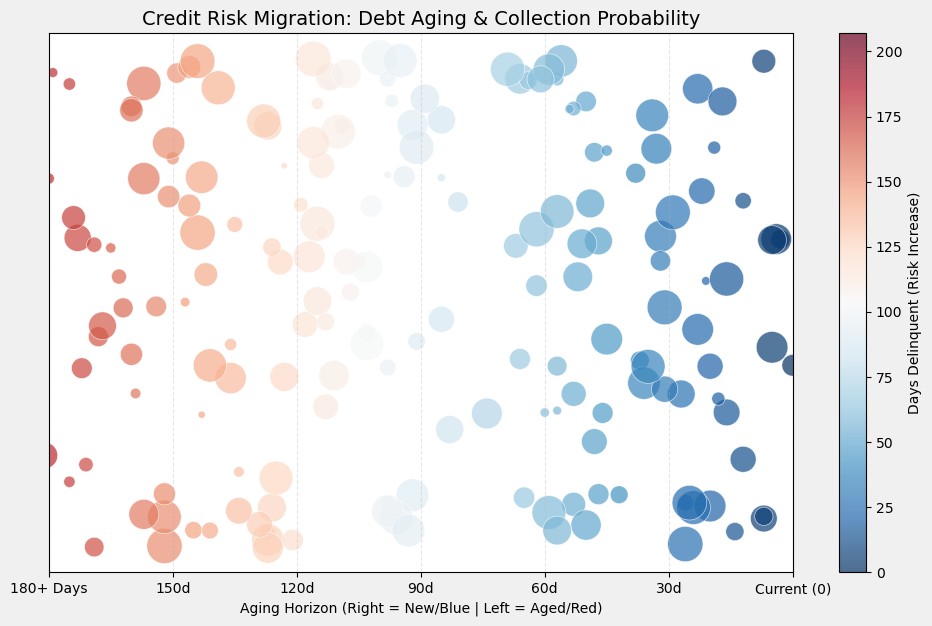

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data
np.random.seed(42)
n_accounts = 200

# Random debt between $500 and $20,000
debt_owed = np.random.uniform(500, 20000, n_accounts)
# Days delinquent from 0 to 200 (to show 180+)
days_delinquent = np.random.randint(0, 210, n_accounts)

# 2. Define Probability of Collection (Logic)
# Probability drops linearly, hitting near-zero at 180 days
prob_collection = np.clip(1 - (days_delinquent / 180), 0, 1)

# 3. Visualization
plt.figure(figsize=(12, 7), facecolor='#f0f0f0')

# Scatter Plot:
# X-axis = Days Delinquent
# Y-axis = Random jitter for vertical spread
# Size (s) = Debt Owed (scaled down for visibility)
# Color (c) = Days Delinquent (mapped to Red-Blue gradient)
scatter = plt.scatter(
    days_delinquent, 
    np.random.uniform(0, 10, n_accounts), 
    s=debt_owed/30, 
    c=days_delinquent, 
    cmap='RdBu_r', # Red-Blue reversed: Blue at low values, Red at high
    alpha=0.7, 
    edgecolors='white',
    linewidth=0.5
)

# 4. Formatting the X-Axis for "Migration"
plt.xlim(180, 0) # Flip axis: 0 on the right, 180 on the left
plt.xticks([180, 150, 120, 90, 60, 30, 0], 
           ['180+ Days', '150d', '120d', '90d', '60d', '30d', 'Current (0)'])

plt.title('Credit Risk Migration: Debt Aging & Collection Probability', fontsize=14)
plt.xlabel('Aging Horizon (Right = New/Blue | Left = Aged/Red)')
plt.yticks([]) # Hide Y-axis as it is just for visual spread

# Colorbar to represent the collection probability decay
cbar = plt.colorbar(scatter)
cbar.set_label('Days Delinquent (Risk Increase)')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()